[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/da380/PartIIStatistics/blob/main/notebooks/03_propagation_of_uncertainty.ipynb)

# 3. Propagation of uncertainty

**What you should get out of this notebook**

- Propagate uncertainties through any calculation by Monte Carlo sampling.
- Use the linearised (Taylor expansion) formula, understand where it comes from and when it fails.
- Understand covariance and correlation, and why correlated errors matter when combining quantities.
- Recognise the familiar rules for sums, products and powers as special cases.

**Tools introduced**

- `stats.multivariate_normal`
- `np.cov`, `np.corrcoef`
- a small finite-difference gradient function, for when differentiating by hand is a chore
- `stats.ecdf`

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd

rng = np.random.default_rng(1)          # random number generator with a fixed seed
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
DATA = "https://raw.githubusercontent.com/da380/PartIIStatistics/main/data/"

## The problem

We have measured quantities $x_1, \dots, x_n$ with known uncertainties, and want to compute some derived quantity

$$
y = f(x_1, \dots, x_n).
$$

Since the inputs are uncertain, so is $y$. How uncertain? Two approaches are in common use. **Monte Carlo propagation** is general and simple: draw random samples of the inputs from their distribution, push each through $f$, and look at the distribution of the outputs. **Linearised propagation** approximates $f$ by a linear function near the mean of the inputs and gives a closed-form expression for the variance of $y$. It is quick and gives insight, but it is an approximation that can fail badly.

We will need a distribution for the vector of inputs $\mathbf{x} = (x_1, \dots, x_n)$. The workhorse is the **multivariate normal distribution**, specified by a mean vector $\bar{\mathbf{x}}$ and an $n \times n$ **covariance matrix** $\mathbf{C}$ whose entries are

$$
C_{ij} = E\big[(x_i - \bar{x}_i)(x_j - \bar{x}_j)\big].
$$

The diagonal entries are the variances $\sigma_i^2$ of the individual inputs. The off-diagonal entries measure how the errors in $x_i$ and $x_j$ vary together; the dimensionless version

$$
\rho_{ij} = \frac{C_{ij}}{\sigma_i \sigma_j}, \qquad -1 \le \rho_{ij} \le 1,
$$

is the **correlation coefficient**. If the errors are independent, $\mathbf{C}$ is diagonal.

## Sampling from a multivariate normal

Here is a two-dimensional example with positively correlated errors. We draw samples and estimate the covariance matrix and correlation back from them with `np.cov` and `np.corrcoef`.

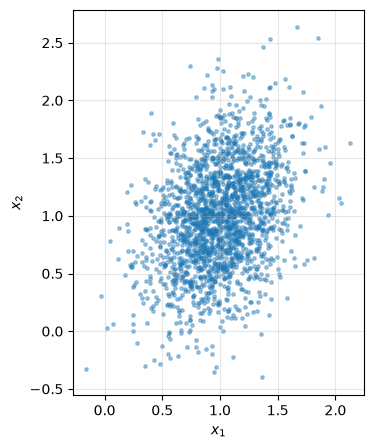

covariance matrix estimated from the samples:
 [[0.098 0.047]
 [0.047 0.203]]
correlation coefficient: 0.332    (exact: 0.354 )


In [ ]:
xbar = np.array([1.0, 1.0])
C = np.array([[0.10, 0.05],
              [0.05, 0.20]])
X = stats.multivariate_normal(mean=xbar, cov=C)

samples = X.rvs(2000, random_state=rng)      # shape (2000, 2)
x1, x2 = samples[:, 0], samples[:, 1]

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x1, x2, s=6, alpha=0.4)
ax.set(xlabel="$x_1$", ylabel="$x_2$", aspect="equal")
plt.show()

print("covariance matrix estimated from the samples:\n", np.round(np.cov(x1, x2), 3))
print("correlation coefficient:", np.round(np.corrcoef(x1, x2)[0, 1], 3),
      "   (exact:", np.round(C[0, 1] / np.sqrt(C[0, 0] * C[1, 1]), 3), ")")

The cloud is elongated along a diagonal: when $x_1$ is high, $x_2$ tends to be high. Try setting the off-diagonal entries to zero, or to $-0.05$, and re-running. (The matrix must be symmetric and *positive definite*; if you make the off-diagonal entry larger than $\sqrt{0.1 \times 0.2} \approx 0.14$, `scipy` will complain.)

## Monte Carlo propagation

Now for the propagation itself. For any function $f$, evaluate it on the samples and you have samples of $y$. We start with a linear function, for which everything can be checked exactly.

mean of y = 5.9743,  standard deviation of y = 1.6686


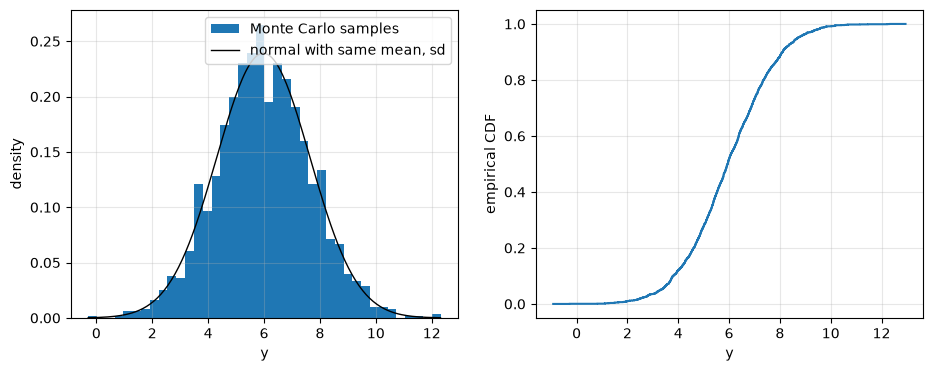

In [ ]:
f = lambda x1, x2: 1 + 2*x1 + 3*x2
y = f(x1, x2)

print(f"mean of y = {y.mean():.4f},  standard deviation of y = {y.std(ddof=1):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(y, bins=40, density=True, label="Monte Carlo samples")
yy = np.linspace(y.min(), y.max(), 200)
ax[0].plot(yy, stats.norm(y.mean(), y.std(ddof=1)).pdf(yy), "k", lw=1, label="normal with same mean, sd")
ax[0].set(xlabel="y", ylabel="density"); ax[0].legend()
stats.ecdf(y).cdf.plot(ax[1])
ax[1].set(xlabel="y", ylabel="empirical CDF")
plt.show()

With samples of $y$ in hand, we can compute anything we like about its distribution: not just the mean and standard deviation but quantiles, the probability that $y$ exceeds a threshold, and so on, all from the empirical CDF. This generality is the great strength of the Monte Carlo approach. Its cost is computing time, which is rarely a problem for simple functions, and the need to specify a full distribution for the inputs, not just their standard deviations.

## Linearised propagation

Write the inputs as $\mathbf{x} = \bar{\mathbf{x}} + \mathbf{z}$, where $\mathbf{z}$ is the zero-mean error. A first-order Taylor expansion about the mean gives

$$
y = f(\bar{\mathbf{x}} + \mathbf{z}) \approx f(\bar{\mathbf{x}}) + \mathbf{g}^{T} \mathbf{z},
\qquad
g_i = \frac{\partial f}{\partial x_i}(\bar{\mathbf{x}}).
$$

To this order $y$ is a linear combination of the errors. Taking the expectation, and then the variance, of the right-hand side gives

$$
\bar{y} \approx f(\bar{\mathbf{x}}), \qquad
\sigma_y^2 \approx \mathbf{g}^T \mathbf{C}\, \mathbf{g} = \sum_{i,j} g_i\, C_{ij}\, g_j .
$$

If the inputs are **uncorrelated** the double sum collapses to

$$
\sigma_y^2 \approx \sum_{i} \left(\frac{\partial f}{\partial x_i}\right)^2 \sigma_i^2 ,
$$

which is the "add the errors in quadrature" rule taught in every laboratory course. Some familiar corollaries, all for uncorrelated inputs:

| $f$ | result |
|---|---|
| $y = x_1 + x_2$ or $x_1 - x_2$ | $\sigma_y^2 = \sigma_1^2 + \sigma_2^2$ |
| $y = x_1 x_2$ or $x_1 / x_2$ | $(\sigma_y / y)^2 = (\sigma_1/x_1)^2 + (\sigma_2/x_2)^2$ |
| $y = x^p$ | $\sigma_y / y = \lvert p \rvert\, \sigma_x / x$ |
| $y = \ln x$ | $\sigma_y = \sigma_x / x$ |

The general formula is easy to apply in code with a matrix product. For our linear $f$ the gradient is $(2, 3)$ and, because $f$ is exactly linear and the inputs are normal, the result is exact rather than approximate.

In [ ]:
g = np.array([2.0, 3.0])
ybar_lin = f(*xbar)
sigma_lin = np.sqrt(g @ C @ g)
print(f"Monte Carlo:  mean = {y.mean():.4f}, sd = {y.std(ddof=1):.4f}")
print(f"linearised:   mean = {ybar_lin:.4f}, sd = {sigma_lin:.4f}")
print(f"if we wrongly ignored the correlation: sd = {np.sqrt(g**2 @ np.diag(C)):.4f}")

Monte Carlo:  mean = 5.9743, sd = 1.6686
linearised:   mean = 6.0000, sd = 1.6733
if we wrongly ignored the correlation: sd = 1.4832


The last line makes an important point: **ignoring a correlation gives the wrong answer**. Here the positive correlation inflates the variance of the sum. For a *difference* of positively correlated quantities the opposite happens: the common part of the errors cancels and the uncertainty is *smaller* than the quadrature rule suggests. This is exactly the principle behind differential measurements, such as measuring the difference between two gravity stations with the same instrument, where drift affects both readings alike.

## When linearisation fails

The Taylor expansion is only accurate if $f$ is close to linear over the range of the input errors. Take a nonlinear function with the same inputs as before.

large input errors:  Monte Carlo mean = 2.685, sd = 2.137;  linearised mean = 2.000, sd = 1.673
input errors 5 times smaller:  Monte Carlo mean = 2.026, sd = 0.332;  linearised mean = 2.000, sd = 0.335


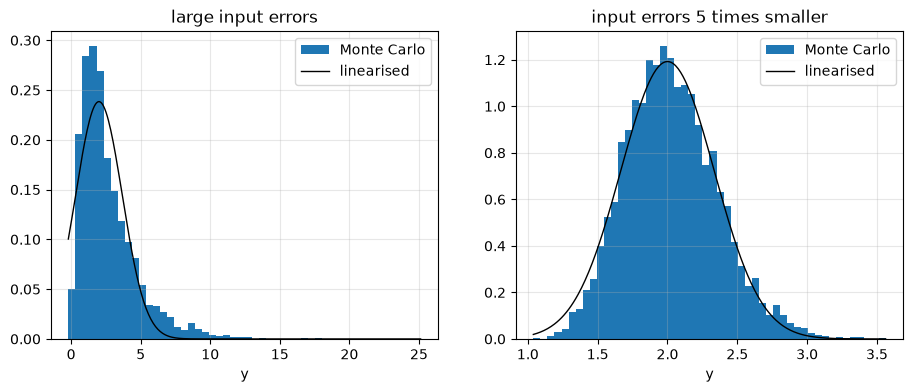

In [ ]:
f = lambda x1, x2: x1**2 + x2**3
df = lambda x1, x2: np.array([2*x1, 3*x2**2])     # the gradient

def compare(C, ax, title):
    X = stats.multivariate_normal(mean=xbar, cov=C)
    s = X.rvs(5000, random_state=rng)
    y = f(s[:, 0], s[:, 1])
    g = df(*xbar)
    ybar_lin, sigma_lin = f(*xbar), np.sqrt(g @ C @ g)
    ax.hist(y, bins=50, density=True, label="Monte Carlo")
    yy = np.linspace(y.min(), y.max(), 300)
    ax.plot(yy, stats.norm(ybar_lin, sigma_lin).pdf(yy), "k", lw=1, label="linearised")
    ax.set(title=title, xlabel="y"); ax.legend()
    print(f"{title}:  Monte Carlo mean = {y.mean():.3f}, sd = {y.std():.3f};  linearised mean = {ybar_lin:.3f}, sd = {sigma_lin:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
compare(C, ax[0], "large input errors")
compare(C / 25, ax[1], "input errors 5 times smaller")
plt.show()

With the original input errors the distribution of $y$ is visibly skewed, the linearised standard deviation is too small, and the linearised mean is biased low: the mean of a nonlinear function is *not* the function of the mean. With input errors five times smaller the linear approximation is excellent. The rule of thumb is that linearisation is safe when the relative errors are small and $f$ is smooth; otherwise use Monte Carlo, which costs nothing extra.

## A worked example: a radiometric age

The age of a rock from a parent–daughter isotope system with decay constant $\lambda$ is

$$
t = \frac{1}{\lambda}\ln\!\left(1 + \frac{D}{P}\right),
$$

where $D/P$ is the measured daughter-to-parent ratio (corrected for any initial daughter). Both $\lambda$ and $D/P$ carry uncertainties. Take the rubidium–strontium system: $\lambda = 1.397 \times 10^{-11}\ \text{yr}^{-1}$ with a relative uncertainty of 1%, and a measured ratio $D/P = 0.0300$ with a relative uncertainty of 2%. Treat the two as uncorrelated.

In [ ]:
lam, sig_lam = 1.397e-11, 0.01 * 1.397e-11
R, sig_R = 0.0300, 0.02 * 0.0300

age = lambda lam, R: np.log(1 + R) / lam / 1e6         # in Myr

# Linearised: partial derivatives by hand
dt_dlam = -np.log(1 + R) / lam**2 / 1e6
dt_dR = 1 / ((1 + R) * lam) / 1e6
sigma_lin = np.sqrt((dt_dlam * sig_lam)**2 + (dt_dR * sig_R)**2)

# Monte Carlo
N = 100_000
lam_s = stats.norm(lam, sig_lam).rvs(N, random_state=rng)
R_s = stats.norm(R, sig_R).rvs(N, random_state=rng)
t_s = age(lam_s, R_s)

print(f"age = {age(lam, R):.1f} Myr")
print(f"linearised uncertainty:   {sigma_lin:.1f} Myr")
print(f"Monte Carlo uncertainty:  {t_s.std():.1f} Myr,   95% interval [{np.percentile(t_s, 2.5):.1f}, {np.percentile(t_s, 97.5):.1f}] Myr")
print(f"contribution from λ alone: {abs(dt_dlam * sig_lam):.1f} Myr;  from D/P alone: {abs(dt_dR * sig_R):.1f} Myr")

age = 2115.9 Myr
linearised uncertainty:   46.8 Myr
Monte Carlo uncertainty:  46.7 Myr,   95% interval [2024.6, 2208.0] Myr
contribution from λ alone: 21.2 Myr;  from D/P alone: 41.7 Myr


The two methods agree because the relative errors are small. The linearised calculation has the extra virtue of showing which input dominates the uncertainty, here the isotope ratio, which tells you where effort would best be spent to improve the age. (The decay constant uncertainty is *systematic*: it is the same for every rock dated with this system, so it does not affect comparisons between Rb–Sr ages, but it does affect comparisons with ages from other systems. This is a correlation between the errors of different ages, and it is exactly the sort of thing the covariance matrix keeps track of.)

If you do not want to differentiate by hand, a finite-difference gradient is perfectly adequate for the linearised formula:

In [ ]:
def gradient(f, x, h=1e-6):
    """Numerical gradient of f at x by central differences (relative step h)."""
    x = np.asarray(x, dtype=float)
    g = np.zeros_like(x)
    for i in range(len(x)):
        dx = np.zeros_like(x); dx[i] = h * abs(x[i]) if x[i] != 0 else h
        g[i] = (f(*(x + dx)) - f(*(x - dx))) / (2 * dx[i])
    return g

g = gradient(age, [lam, R])
Cin = np.diag([sig_lam**2, sig_R**2])
print(f"linearised uncertainty via numerical gradient: {np.sqrt(g @ Cin @ g):.1f} Myr")

linearised uncertainty via numerical gradient: 46.8 Myr


## Summary

- Monte Carlo propagation is general: sample the inputs, evaluate the function, study the output samples.
- The linearised formula $\sigma_y^2 = \mathbf{g}^T \mathbf{C}\, \mathbf{g}$ is quick, reveals which inputs matter, and reduces to the quadrature rule for uncorrelated inputs.
- Linearisation fails when the function is strongly nonlinear over the range of input errors; the mean of $f$ is then not $f$ of the mean.
- Correlated errors change the answer. Positive correlation inflates the error of a sum and shrinks the error of a difference.

## Exercises

### Exercise 1

The density of a rock sample is computed from its mass $m = 152.3 \pm 0.2$ g and volume $V = 56.1 \pm 0.6$ cm$^3$ (one standard deviation, uncorrelated, normal). Compute the density and its uncertainty by (a) the linearised formula for a quotient and (b) Monte Carlo. Do they agree?

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

```python
m, sm = 152.3, 0.2
V, sV = 56.1, 0.6
rho = m / V
s_lin = rho * np.sqrt((sm/m)**2 + (sV/V)**2)
rho_s = stats.norm(m, sm).rvs(100_000, random_state=rng) / stats.norm(V, sV).rvs(100_000, random_state=rng)
print(f"density = {rho:.3f} g/cm^3;  linearised sd = {s_lin:.3f};  Monte Carlo sd = {rho_s.std():.3f}")
```

Both give about $2.715 \pm 0.029$ g cm$^{-3}$. The relative errors are about 0.1% and 1%, comfortably in the linear regime, and the volume dominates.

</details>

### Exercise 2

Two gravity readings $g_1$ and $g_2$ are taken with the same instrument at two stations. Each has an independent random error of standard deviation 0.05 mGal, but both are also affected by a common instrument drift error of standard deviation 0.10 mGal (the same for both readings). Write down the $2 \times 2$ covariance matrix of $(g_1, g_2)$ and find the uncertainty of the difference $g_2 - g_1$ (a) correctly, and (b) if the correlation were ignored. Confirm by sampling from `stats.multivariate_normal`.

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

Each reading has variance $0.05^2 + 0.10^2$, and the two share the drift so their covariance is $0.10^2$:

$$
\mathbf{C} = \begin{pmatrix} 0.0125 & 0.0100 \\ 0.0100 & 0.0125 \end{pmatrix}.
$$

The difference has gradient $\mathbf{g} = (-1, 1)$.

```python
C = np.array([[0.05**2 + 0.10**2, 0.10**2],
              [0.10**2, 0.05**2 + 0.10**2]])
g = np.array([-1.0, 1.0])
print(f"correct sd of difference:           {np.sqrt(g @ C @ g):.4f} mGal")
print(f"ignoring the correlation:           {np.sqrt(g**2 @ np.diag(C)):.4f} mGal")
s = stats.multivariate_normal([0, 0], C).rvs(100_000, random_state=rng)
print(f"Monte Carlo:                        {(s[:, 1] - s[:, 0]).std():.4f} mGal")
```

The drift cancels in the difference, leaving only $\sqrt{2} \times 0.05 \approx 0.071$ mGal, whereas ignoring the correlation would give 0.158 mGal. Differential measurements are precise precisely because of correlated errors.

</details>

### Exercise 3

For $y = x_1^2 + x_2^3$ with the covariance matrix `C` used above, scale `C` by a range of factors (say `C * k` for `k` from 0.01 to 2) and plot the ratio of the linearised standard deviation to the Monte Carlo standard deviation against `k`. At what size of input error does the linearised formula become more than 10% wrong?

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

```python
f = lambda x1, x2: x1**2 + x2**3
df = lambda x1, x2: np.array([2*x1, 3*x2**2])
ks = np.logspace(-2, np.log10(2), 15)
ratio = []
for k in ks:
    s = stats.multivariate_normal(xbar, C * k).rvs(20_000, random_state=rng)
    y = f(s[:, 0], s[:, 1])
    g = df(*xbar)
    ratio.append(np.sqrt(g @ (C * k) @ g) / y.std())
fig, ax = plt.subplots()
ax.semilogx(ks, ratio, "o-")
ax.axhline(0.9, color="k", ls="--", lw=1)
ax.set(xlabel="scale factor k on the covariance", ylabel="linearised sd / Monte Carlo sd")
plt.show()
```

The ratio drops below 0.9 once $k$ is around 0.3, i.e. when the standard deviation of $x_2$ is about $\sqrt{0.2 \times 0.3} \approx 0.25$, a 25% relative error on a quantity that enters cubed.

</details>